# Optical cluster bias $b_{\lambda^{\rm ob}}(R)$ -- reproducing Costanzi 2026 Fig.~2

We show the scale-dependent selection bias at fixed $\lambda^{\rm ob}=20$, $z^{\rm ob}=0.5$ as a function of physical radius $R = \theta \cdot D_A(z^{\rm ob})$, for several values of $\Delta^{\rm prj} = \lambda^{\rm ob} - \lambda^{\rm tr}$.

The curves are built from paper eq.~6:
$$b_{\lambda^{\rm ob}}(\theta) = b^0_{\lambda^{\rm ob}} + \frac{b^\infty_{\lambda^{\rm ob}} - b^0_{\lambda^{\rm ob}}}{1 + e^{-k(\theta-\theta_0)}},\qquad k=2.5/\theta_\lambda,\ \theta_0=\theta_\lambda/2.$$

- $b^\infty_{\lambda^{\rm ob}} = b_{\rm eff} \cdot (1+0.13\,\delta^{\rm prj})$ (empirical closure, eq.~7).
- $b^0_{\lambda^{\rm ob}}$ from eq.~8, computed via the operator $\mathcal{P}[X]$ (eq.~9).
- $\mathcal{P}$ uses the split-at-exclusion $\theta$-grid and the CDF-based adaptive $z$-grid (the default `z_scheme='C'` in `RichnessSelection`).

The orange line is the $\lambda^{\rm tr}$-marginalised bias (eq.~10).

In [1]:
%%time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import coolwarm
from matplotlib.colors import Normalize

from richness_selection import (
    Cosmology, PkGrid, HMF, Bias, MOR, XiNL, SelBias,
)
from richness_selection.sigma_m import SigmaM

cosmo    = Cosmology()
pk       = PkGrid(cosmo)
sigma_m  = SigmaM(pk)
hmf      = HMF(sigma_m)
bias     = Bias(sigma_m)
mor      = MOR()
xi_nl    = XiNL(cosmo)
sel_bias = SelBias(cosmo, pk, hmf, bias, mor, xi_nl=xi_nl)
# default z_scheme='C' (CDF-based adaptive); theta grid auto-splits at exclusion.

CPU times: user 4.47 s, sys: 892 ms, total: 5.36 s
Wall time: 2.66 s


In [2]:
%%time
lob = 20.0
zob = 0.5

pipe = sel_bias.bias_pipeline(lob, zob, ltr=lob - 10.0)
print('bias_pipeline(lob=20, zob=0.5, ltr=10):')
for k, v in pipe.items():
    if isinstance(v, float):
        print(f'  {k:>12s} = {v:+.4e}')

bias_pipeline(lob=20, zob=0.5, ltr=10):
     delta_prj = +2.0605e+00
        b_zero = +5.6970e+01
       b_infty = +4.3973e+00
           lob = +2.0000e+01
           zob = +5.0000e-01
            P1 = +1.9876e+00
            I1 = +2.4748e-01
            I2 = +3.6902e-01
         b_eff = +3.4682e+00
     Delta_RND = +3.2674e+00
         denom = +1.2154e-01
           ltr = +1.0000e+01
CPU times: user 9.23 s, sys: 68.1 ms, total: 9.3 s
Wall time: 2.56 s


## Figure 2 (Costanzi 2026) -- $b_{\lambda^{\rm ob}}(R)$ color-coded by $\Delta^{\rm prj}$

Converting $\theta \to R$ via $R = \theta \, D_A(z^{\rm ob}) / (1+z^{\rm ob}) = \theta \, \chi(z^{\rm ob}) / (1+z^{\rm ob})^2$ in **comoving** Mpc/$h$; the paper uses physical Mpc/$h$ which differs by a factor of $(1+z^{\rm ob})$.  We plot on comoving Mpc/$h$ for consistency with the rest of the package (the paper axis is $R$ [Mpc/h] which it labels physical).

Paper values at the reference point for visual comparison:
- $b_{\rm eff}(\lambda^{\rm ob}\!=\!20, z^{\rm ob}\!=\!0.5) \approx 3.5$
- $\Delta^{\rm prj}=2$ &rarr; $b(R=0)$ goes slightly negative
- $\Delta^{\rm prj}=10$ &rarr; $b(R=0) \approx 50$
- $\Delta^{\rm prj}=20$ &rarr; $b(R=0) \approx 800$ (off log-scale in the paper)

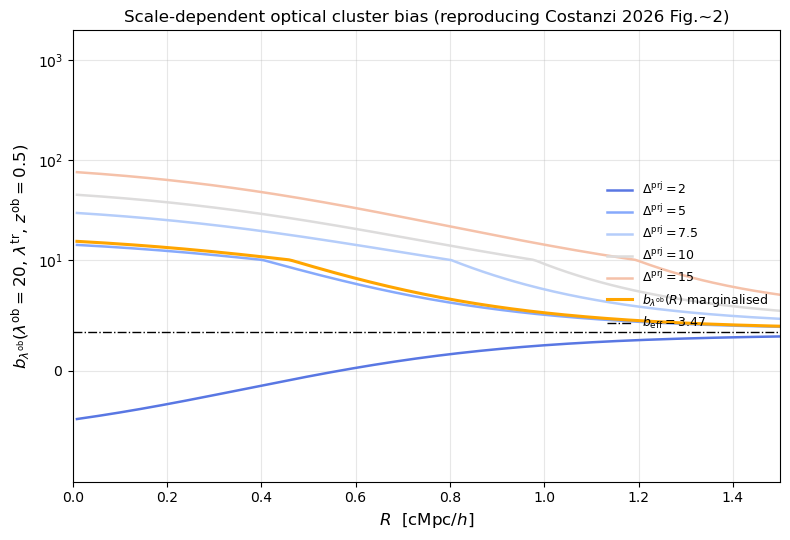

CPU times: user 590 ms, sys: 95.6 ms, total: 685 ms
Wall time: 412 ms


In [3]:
%%time
# Pre-compute the P operator once at (lob, zob)
pre = sel_bias.bias_precompute(lob, zob)
b_eff = pre['b_eff']

# theta grid spanning 0 to ~ R = 1.5 cMpc/h
theta_lob = sel_bias._theta_lob(lob, zob)
chi_o     = float(cosmo.chi(zob))
R_max     = 1.5   # cMpc/h
theta_max = R_max / chi_o * (1.0 + zob)
thetas    = np.linspace(1e-5, theta_max, 200)
R_arr     = thetas * chi_o / (1.0 + zob)   # cMpc/h  (we plot R in cMpc/h)

# Sweep Delta_prj
deltas = [2.0, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0]
colors = coolwarm(np.linspace(0.1, 0.9, len(deltas)))

# Marginalised bias
bmarg = sel_bias.b_sel_marginalised(thetas, lob, zob, precomp=pre)

# Layout: main panel with symlog y (paper-style), inset showing Delta_prj<2 behaviour
fig, ax = plt.subplots(figsize=(8.0, 5.5))

for d, col in zip(deltas, colors):
    ltr = lob - d
    if ltr <= 0:
        continue
    b = sel_bias.b_lob_theta(thetas, ltr, zob, lob, precomp=pre)
    ax.plot(R_arr, b, color=col, lw=1.8,
            label=fr'$\Delta^{{\rm prj}}={d:g}$')

# Marginalised (paper's orange line)
ax.plot(R_arr, bmarg, color='orange', lw=2.2, ls='-',
        label=r'$b_{\lambda^{\rm ob}}(R)$ marginalised')

# b_eff reference (paper's black dot-dashed)
ax.axhline(b_eff, color='k', ls='-.', lw=1.0,
           label=fr'$b_{{\rm eff}}={b_eff:.2f}$')

ax.set_yscale('symlog', linthresh=10.0)
ax.set_xlabel(r'$R$  [cMpc/$h$]', fontsize=12)
ax.set_ylabel(r'$b_{\lambda^{\rm ob}}(\lambda^{\rm ob}=20,\,\lambda^{\rm tr},\,z^{\rm ob}=0.5)$',
              fontsize=12)
ax.set_title(r'Scale-dependent optical cluster bias (reproducing Costanzi 2026 Fig.~2)')
ax.set_xlim(0.0, R_max)
ax.set_ylim(-10.0, 2000.0)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='center right', fontsize=9, frameon=False, ncol=1)
plt.tight_layout()
plt.show()

## Complementary view: $b_{\lambda^{\rm ob}}(\theta)$ on a symlog $\theta / \theta_\lambda$ axis

Same quantity, but with $\theta/\theta_\lambda^{\rm tgt}$ on the x-axis.  The sigmoid transition is centered at $\theta_0 = \theta_\lambda/2$.

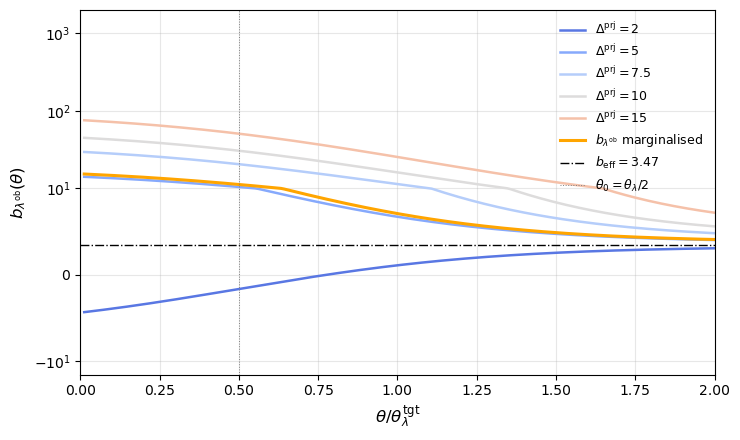

CPU times: user 260 ms, sys: 11.3 ms, total: 272 ms
Wall time: 273 ms


In [4]:
%%time
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for d, col in zip(deltas, colors):
    ltr = lob - d
    if ltr <= 0:
        continue
    b = sel_bias.b_lob_theta(thetas, ltr, zob, lob, precomp=pre)
    ax.plot(thetas / theta_lob, b, color=col, lw=1.8,
            label=fr'$\Delta^{{\rm prj}}={d:g}$')

ax.plot(thetas / theta_lob, bmarg, color='orange', lw=2.2,
        label=r'$b_{\lambda^{\rm ob}}$ marginalised')
ax.axhline(b_eff, color='k', ls='-.', lw=1.0,
           label=fr'$b_{{\rm eff}}={b_eff:.2f}$')
ax.axvline(0.5, color='gray', ls=':', lw=0.7, label=r'$\theta_0=\theta_\lambda/2$')

ax.set_yscale('symlog', linthresh=10.0)
ax.set_xlabel(r'$\theta / \theta_\lambda^{\rm tgt}$', fontsize=12)
ax.set_ylabel(r'$b_{\lambda^{\rm ob}}(\theta)$', fontsize=12)
ax.set_xlim(0.0, 2.0)
ax.set_ylim(-15.0, 2000.0)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right', fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## Small and negative $\Delta^{\rm prj}$ (linear scale)

For $\Delta^{\rm prj}$ below the average background contribution $\langle\Delta^{\rm prj}_{\rm bkg}\rangle\sim 2$, the paper predicts the small-scale bias turns negative (preferentially under-dense lines of sight).

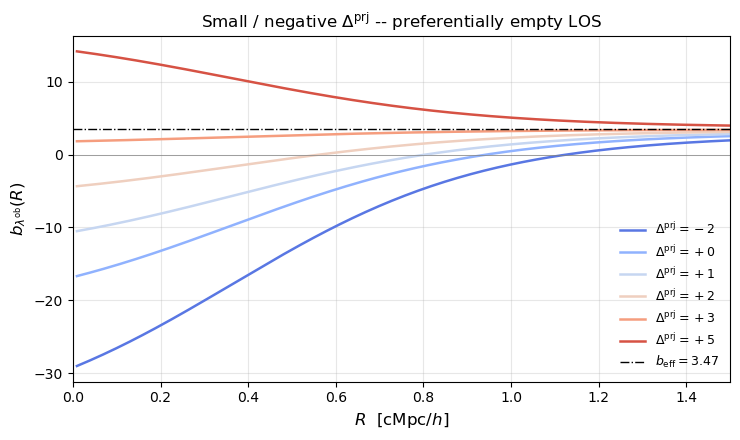

CPU times: user 235 ms, sys: 12.2 ms, total: 247 ms
Wall time: 247 ms


In [5]:
%%time
deltas_small = [-2.0, 0.0, 1.0, 2.0, 3.0, 5.0]
colors_small = coolwarm(np.linspace(0.1, 0.9, len(deltas_small)))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for d, col in zip(deltas_small, colors_small):
    ltr = lob - d
    if ltr <= 0:
        continue
    b = sel_bias.b_lob_theta(thetas, ltr, zob, lob, precomp=pre)
    ax.plot(R_arr, b, color=col, lw=1.8,
            label=fr'$\Delta^{{\rm prj}}={d:+g}$')

ax.axhline(b_eff, color='k', ls='-.', lw=1.0,
           label=fr'$b_{{\rm eff}}={b_eff:.2f}$')
ax.axhline(0.0, color='gray', lw=0.5)
ax.set_xlabel(r'$R$  [cMpc/$h$]', fontsize=12)
ax.set_ylabel(r'$b_{\lambda^{\rm ob}}(R)$', fontsize=12)
ax.set_title(r'Small / negative $\Delta^{\rm prj}$ -- preferentially empty LOS')
ax.set_xlim(0.0, R_max)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, frameon=False)
plt.tight_layout()
plt.show()